# 4_models  
**Цель:** сравнить качество одиночной модели логистической регрессии и стекинга (ансамбля) на датасете Titanic.  
**Ключевая метрика:** Recall т.к. важно минимизировать пропуски выживших.

### 1. Загрузка и предобработка данных

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay, precision_score
from sklearn.base import clone
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

In [34]:
def preprocess_titanic(df, target_col='Survived', test_size=0.2, random_state=42):
    """
    Полный пайплайн обработки данных датасета Titanic

    Parameters:
    -----------
    df : pd.DataFrame                    - изначальный датасет
    target_col : str, default='Survived' - имя целевой переменной
    test_size : float, default=0.2.      - доля тестовой выборки от 0 до 1
    random_state : int, default=42       - для воспроизводимости разделения

    Returns:
    --------
    X_train_scaled : np.ndarray          - масштабированные признаки обучающей выборки
    X_test_scaled : np.ndarray           - масштабированные признаки тестовой выборки
    y_train : pd.Series                  - целевая переменная для обучения
    y_test : pd.Series                   - целевая переменная для тестирования
    scaler : StandardScaler              - обученный scaler для применения к новым данным
    feature_names : list                 - список названий признаков, порядок соответствует столбцам X_train_scaled
    """
    # Работа с копией, чтобы не изменять исходный DataFrame
    data = df.copy()

    # 1. Удаление ненужных столбцов
    data.drop(columns=['PassengerId', 'Ticket', 'Cabin'], inplace=True, errors='ignore')

    # 2. Обработка пропусков
    data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    data['Age'] = data.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

    # 3. Обработка выбросов
    data['Fare'] = winsorize(data['Fare'].to_numpy(), limits=(0, 0.01))

    # 4. Создание новых признаков
    data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Rare', 'Ms': 'Rare', 'Mme': 'Rare', 'Don': 'Rare',
        'Lady': 'Rare', 'Sir': 'Rare', 'Capt': 'Rare', 'Countess': 'Rare',
        'Jonkheer': 'Rare'
    }
    data['Title'] = data['Title'].map(title_mapping).fillna('Rare')

    data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 19, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])
    data['MinorAge'] = (data['Age'] < 18).astype(int)
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    data['FareGroup'] = pd.qcut(data['Fare'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'], duplicates='drop')

    # 5. Удаление исходных текстовых столбцов, которые больше не нужны
    data.drop(columns=['Name'], inplace=True, errors='ignore')

    # 6. One‑Hot Encoding категориальных признаков
    categorical_features = ['Embarked', 'Title', 'AgeGroup', 'FareGroup']
    data = pd.get_dummies(data, columns=categorical_features, drop_first=True)
    bool_cols = data.select_dtypes(include='bool').columns
    data[bool_cols] = data[bool_cols].astype(int)

    # 7. Разделение на обучающую и тестовую выборки
    X = data.drop(columns=[target_col])
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

    # 8. Масштабирование числовых признаков только на train
    numeric_features = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch', 'Pclass']

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

    feature_names = X_train_scaled.columns.tolist()

    return X_train_scaled, X_test_scaled, y_train, y_test, X_train, X_test, scaler, feature_names

In [35]:
df = pd.read_csv('C:\\Users\\717ll\\PMO_lab_6\\Titanic-Dataset.csv')
X_train_scaled, X_test_scaled, y_train, y_test, X_train, X_test, scaler, features = preprocess_titanic(df)
print(f'Train: {X_train_scaled.shape}\nTest: {X_test_scaled.shape}\nFeatures: {features}')

Train: (712, 21)
Test: (179, 21)
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'MinorAge', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareGroup_Medium', 'FareGroup_High', 'FareGroup_VeryHigh']


### 2. Выбор базовых моделей и мета-модели

**Базовые модели:**
- **Логистическая регрессия** – линейная, интерпретируемая, стабильная.
- **SVC с RBF‑ядром** – нелинейная, улавливает сложные зависимости.
- **GradientBoosting** – мощный бустинг, хорошо работает с табличными данными.

**Мета-модель:** логистическая регрессия. Простая, устойчива к переобучению.

In [36]:
base_models = [
    ('lr', LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=500)),
    ('svm', SVC(kernel='rbf', gamma='scale', probability=True, random_state=42)),
    ('gb', GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42))
]
meta_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

### 3. Обучение одиночной модели

In [37]:
def print_metrics(y_true, y_pred, y_prob, model_name="Модель"):
    print(f"\n{model_name}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print(f"Log Loss:  {log_loss(y_true, y_prob):.3f}")
    cm = confusion_matrix(y_true, y_pred)
    print(f"Матрица ошибок:\n TN={cm[0,0]} FP={cm[0,1]}\n FN={cm[1,0]} TP={cm[1,1]}")

In [38]:
single_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=500)
single_model.fit(X_train_scaled, y_train)
y_pred_prob_single = single_model.predict_proba(X_test_scaled)[:, 1]
y_pred_class_single = (y_pred_prob_single >= 0.5).astype(int)

print_metrics(y_test, y_pred_class_single, y_pred_prob_single, "Логистическая регрессия")


Логистическая регрессия
Accuracy:  0.827
Precision: 0.757
Recall:    0.812
F1-score:  0.783
Log Loss:  0.435
Матрица ошибок:
 TN=92 FP=18
 FN=13 TP=56


### 4. Ручная реализация стекинга

In [39]:
# 0. Приведение к numpy
X_train_np = np.array(X_train_scaled)
X_test_np = np.array(X_test_scaled)
y_train_np = np.array(y_train)

# 1. Кросс-валидация
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Инициализация мета-признаков
meta_features_train = np.zeros((X_train_np.shape[0], len(base_models)))
meta_features_test = np.zeros((X_test_np.shape[0], len(base_models)))

# 3. Генерация OOF-признаков
for i, (name, model) in enumerate(base_models):
    test_preds = np.zeros((n_splits, X_test_np.shape[0]))

    for j, (train_idx, val_idx) in enumerate(kf.split(X_train_np, y_train_np)):
        model_clone = clone(model)

        X_tr = X_train_np[train_idx]
        y_tr = y_train_np[train_idx]
        X_val = X_train_np[val_idx]

        model_clone.fit(X_tr, y_tr)

        # OOF предсказания train
        meta_features_train[val_idx, i] = model_clone.predict_proba(X_val)[:, 1]

        # Предсказания test
        test_preds[j, :] = model_clone.predict_proba(X_test_np)[:, 1]

    # Усреднение предсказаний по фолдам
    meta_features_test[:, i] = test_preds.mean(axis=0)

# 4. Масштабирование мета-признаков
scaler_meta = StandardScaler()
meta_features_train_scaled = scaler_meta.fit_transform(meta_features_train)
meta_features_test_scaled = scaler_meta.transform(meta_features_test)

# 5. Обучение мета-модели
meta_model.fit(meta_features_train_scaled, y_train_np)

# 6. Предсказания
y_pred_prob_manual = meta_model.predict_proba(meta_features_test_scaled)[:, 1]
y_pred_class_manual = (y_pred_prob_manual >= 0.5).astype(int)

# 7. Оценка
print_metrics(y_test, y_pred_class_manual, y_pred_prob_manual, "Ручной стекинг")


Ручной стекинг
Accuracy:  0.855
Precision: 0.803
Recall:    0.826
F1-score:  0.814
Log Loss:  0.415
Матрица ошибок:
 TN=96 FP=14
 FN=12 TP=57


#### 5. Стекинг с использованием sklearn.ensemble.StackingClassifier

In [40]:
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
stacking_clf.fit(X_train_scaled, y_train)
y_pred_prob_stack = stacking_clf.predict_proba(X_test_scaled)[:, 1]
y_pred_class_stack = (y_pred_prob_stack >= 0.5).astype(int)
print_metrics(y_test, y_pred_class_stack, y_pred_prob_stack, "Стекинг sklearn")


Стекинг sklearn
Accuracy:  0.855
Precision: 0.812
Recall:    0.812
F1-score:  0.812
Log Loss:  0.424
Матрица ошибок:
 TN=97 FP=13
 FN=13 TP=56


#### 6. Сравнительный анализ и визуализация

#### График 1. Сравнение метрик


На графике представлено сравнение качества одиночной модели и ансамбля  по трём метрикам: Recall, F1-score и Accuracy на тестовой выборке.

**Основные наблюдения:**

- **Recall не изменился**  
  Ансамбль не улучшил способность модели находить положительный класс. Это означает, что с точки зрения основной метрики задача не получила выигрыша.

- **F1-score увеличился**  
  Улучшение F1-score говорит о более сбалансированной работе модели. Ансамбль лучше сочетает precision и recall.

- **Accuracy увеличилась**  
  Общая точность классификации выросла, что указывает на более стабильные предсказания ансамбля.

Таким образом, ансамбль делает модель более сбалансированной, но не решает основную задачу - увеличение Recall.

**Вывод** использование стекинга частично оправдано, однако его преимущество ограничено, и с точки зрения целевой метрики (Recall)  выигрыша не достигнуто.

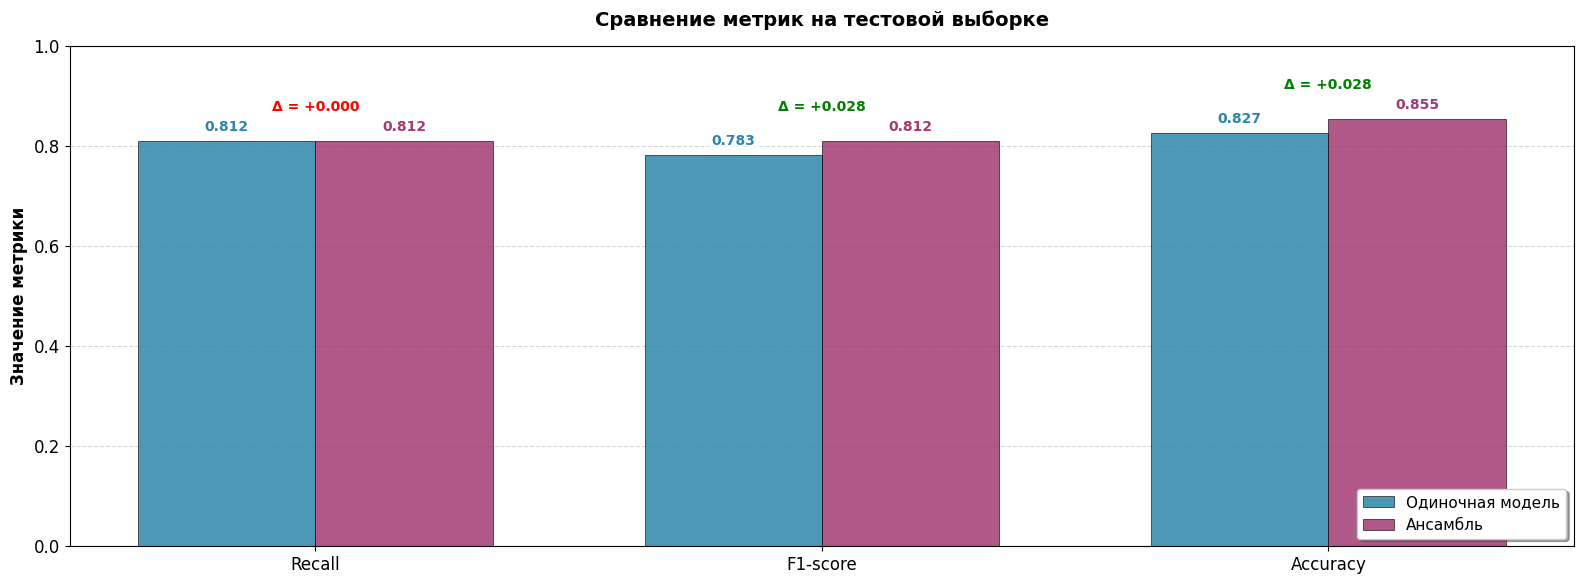

In [41]:
# Метрики
single_recall = recall_score(y_test, y_pred_class_single)
single_f1 = f1_score(y_test, y_pred_class_single)
single_acc = accuracy_score(y_test, y_pred_class_single)

stack_recall = recall_score(y_test, y_pred_class_stack)
stack_f1 = f1_score(y_test, y_pred_class_stack)
stack_acc = accuracy_score(y_test, y_pred_class_stack)

metrics = ['Recall', 'F1-score', 'Accuracy']
single_scores = [single_recall, single_f1, single_acc]
stack_scores = [stack_recall, stack_f1, stack_acc]

x = np.arange(len(metrics))
width = 0.35

# Стиль
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')

# Цвета
color_single = '#2E86AB'
color_stack = '#A23B72'

rects1 = ax.bar(x - width/2, single_scores, width, label='Одиночная модель', color=color_single, edgecolor='black', linewidth=0.5, alpha=0.85)
rects2 = ax.bar(x + width/2, stack_scores, width, label='Ансамбль', color=color_stack, edgecolor='black', linewidth=0.5, alpha=0.85)

# Настройка осей и сетки
ax.set_ylabel('Значение метрики', fontsize=12, fontweight='semibold')
ax.set_title('Сравнение метрик на тестовой выборке', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Легенда
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=11)

# Аннотации значений
def annotate_bars(rects, color='black'):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=color,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor='none', alpha=0.7))

annotate_bars(rects1, color_single)
annotate_bars(rects2, color_stack)

# Разница над столбцами
for i, metric in enumerate(metrics):
    delta = stack_scores[i] - single_scores[i]
    delta_color = 'green' if delta > 0 else 'red'
    ax.text(x[i], max(single_scores[i], stack_scores[i]) + 0.06,
            f'Δ = {delta:+.3f}', ha='center', fontsize=10,
            color=delta_color, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor='none'))

# Подпись источника данных
ax.text(0.99, 0.01, 'Данные: Titanic test set (n=179)',transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

#### График 2. Распределение предсказанных вероятностей

На графиках показано распределение предсказанных вероятностей выживания для двух моделей: ансамбля (слева) и одиночной модели (справа). Для каждого класса построены гистограммы, а также отмечены медианные значения вероятностей.

**Основные наблюдения**
- **Ансамбль** демонстрирует более чёткое разделение классов:
  - вероятности для погибших сосредоточены в низком диапазоне (~0.1–0.3),
  - вероятности для выживших — в высоком (~0.75–0.9).
- У ансамбля медианы классов дальше друг от друга, что также указывает на лучшее разделение.
- Ансамбль чаще выдаёт экстремальные вероятности, близкие к 0 или 1. Это признак более уверенных предсказаний

**Вывод**

Ансамблевая модель лучше разделяет классы, даёт более уверенные предсказания,уменьшает область неопределённости.
Это объясняет рост метрик **F1-score** и **Accuracy**, наблюдаемый ранее.

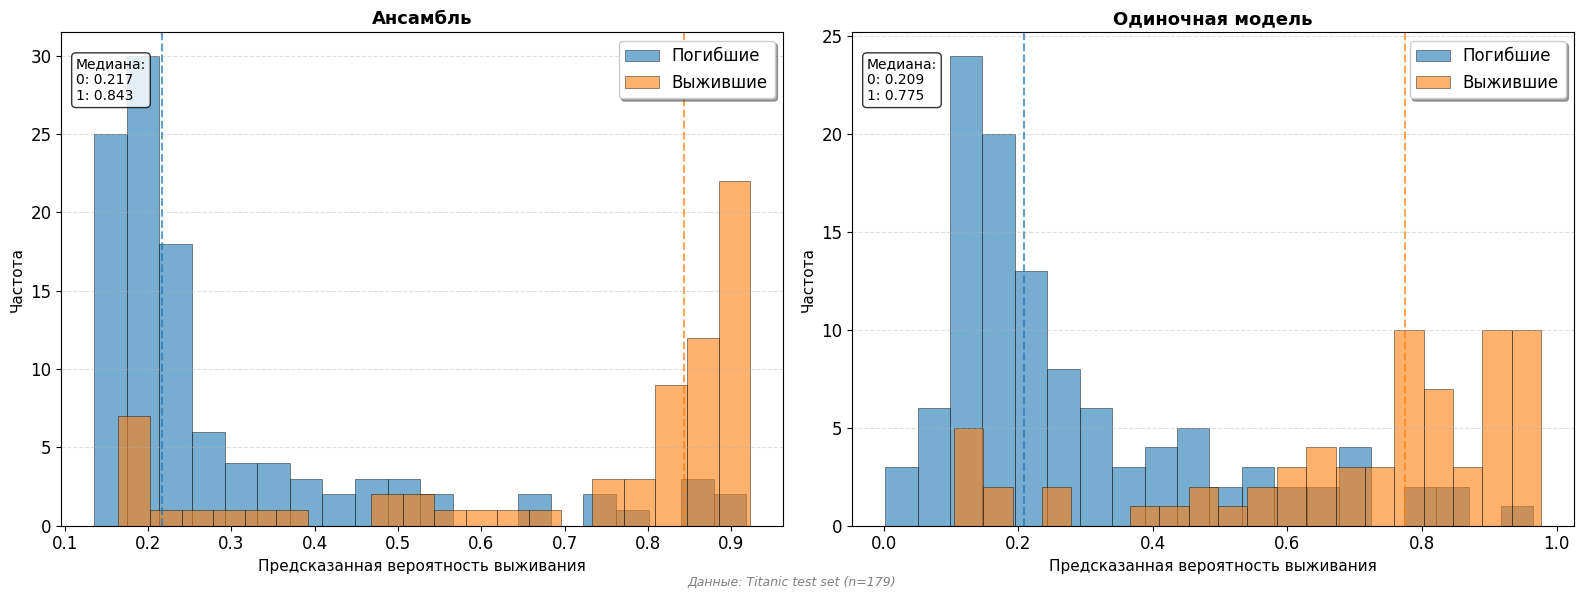

In [42]:
# Настройка стиля
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Цвета
color_class0 = '#1f77b4'
color_class1 = '#ff7f0e'

# Стекинг
ax = axes[0]
# Гистограммы
n0, bins0, _ = ax.hist(y_pred_prob_stack[y_test == 0], bins=20, alpha=0.6, color=color_class0, edgecolor='black', linewidth=0.5, label='Погибшие')
n1, bins1, _ = ax.hist(y_pred_prob_stack[y_test == 1], bins=20, alpha=0.6, color=color_class1, edgecolor='black', linewidth=0.5, label='Выжившие')

# Медианы
med0 = np.median(y_pred_prob_stack[y_test == 0])
med1 = np.median(y_pred_prob_stack[y_test == 1])
ax.axvline(med0, color=color_class0, linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(med1, color=color_class1, linestyle='--', linewidth=1.5, alpha=0.7)

# Подписи
ax.set_title('Ансамбль', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказанная вероятность выживания', fontsize=11)
ax.set_ylabel('Частота', fontsize=11)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Текст с медианой
ax.text(0.02, 0.95, f'Медиана:\n0: {med0:.3f}\n1: {med1:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Одиночная модель
ax = axes[1]
ax.hist(y_pred_prob_single[y_test == 0], bins=20, alpha=0.6, color=color_class0, edgecolor='black', linewidth=0.5, label='Погибшие')
ax.hist(y_pred_prob_single[y_test == 1], bins=20, alpha=0.6, color=color_class1, edgecolor='black', linewidth=0.5, label='Выжившие')

med0_s = np.median(y_pred_prob_single[y_test == 0])
med1_s = np.median(y_pred_prob_single[y_test == 1])
ax.axvline(med0_s, color=color_class0, linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(med1_s, color=color_class1, linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title('Одиночная модель', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказанная вероятность выживания', fontsize=11)
ax.set_ylabel('Частота', fontsize=11)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.text(0.02, 0.95, f'Медиана:\n0: {med0_s:.3f}\n1: {med1_s:.3f}',transform=ax.transAxes, fontsize=10, verticalalignment='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
fig.text(0.5, 0.01, 'Данные: Titanic test set (n=179)', ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

#### График 3. Матрицы ошибок

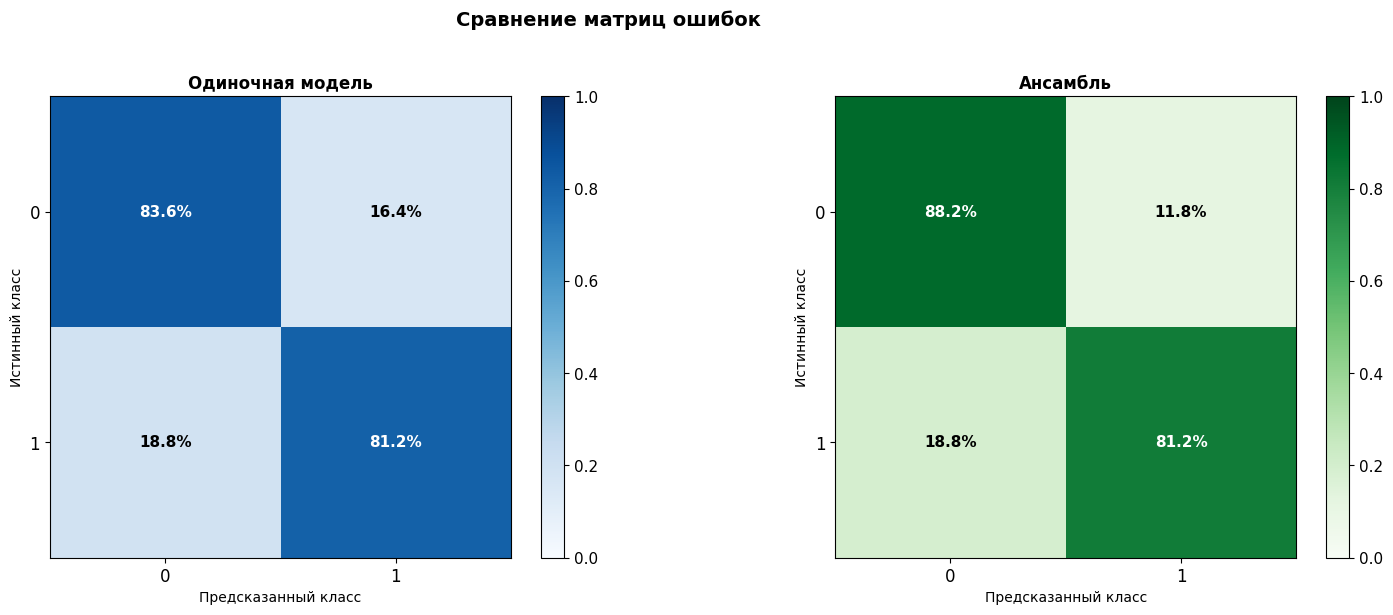

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

def plot_custom_cm(ax, y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'])
    ax.set_xlabel('Предсказанный класс', fontsize=10)
    ax.set_ylabel('Истинный класс', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = 'white' if value > 0.5 else 'black'
            ax.text(j, i, f'{value:.1%}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_custom_cm(axes[0], y_test, y_pred_class_single, 'Одиночная модель', cmap='Blues')
plot_custom_cm(axes[1], y_test, y_pred_class_stack, 'Ансамбль', cmap='Greens')
fig.suptitle('Сравнение матриц ошибок', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### 7. Сохранение полного пайплайна

In [ ]:
full_pipeline = Pipeline([('scaler', scaler), ('stacking', stacking_clf)])
joblib.dump(full_pipeline, 'titanic_stacking_pipeline.pkl')

# Список финальных признаков 
feature_names = X_train_scaled.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

# Медианы возраста по классам 
age_medians = df.groupby('Pclass')['Age'].median().to_dict()
joblib.dump(age_medians, 'age_medians.pkl')

# 99-й перцентиль тарифа для winsorize
fare_99th = df['Fare'].quantile(0.99)
joblib.dump(fare_99th, 'fare_99th.pkl')

# Границы квартилей для FareGroup
# В ноутбуке использовался pd.qcut(..., q=4, labels=...)
# Найдём квантили 0.25, 0.5, 0.75 на обучающем наборе (X_train)
fare_quantiles = X_train['Fare'].quantile([0.25, 0.5, 0.75]).tolist()
joblib.dump(fare_quantiles, 'fare_quantiles.pkl')

print("Артефакты сохранены.")

Артефакты сохранены.


# Финальный отчёт 

## 1. Цель работы
Построить и сравнить одиночную модель логистической регрессии и ансамбль на основе стекинга для предсказания выживания пассажиров Титаника. Ключевая метрика — полнота, так как важнее не пропустить выживших.

## 2. Этапы выполнения

**1. Анализ данных**

Проведён разведочный анализ. Выявлено, что пол, класс билета и возраст сильнее всего влияют на выживаемость. Женщины и пассажиры первого класса выживали чаще.

**2. Подготовка данных**

Заполнены пропуски возраста медианой по классу билета. Из имён извлечён признак титул. Созданы признаки размер семьи, одиночество на борту и возрастная группа. Категории преобразованы в числа, числовые признаки стандартизированы.

**3. Базовая модель**

Обучена логистическая регрессия с балансировкой весов классов. Модель показала хороший результат, что подтвердило корректность инженерии признаков.

**4. Построение ансамбля**

Собран стек из трёх базовых моделей: логистической регрессии, метода опорных векторов с RBF-ядром и градиентного бустинга. Мета-моделью выбрана логистическая регрессия. Для генерации признаков использована 5-блочная кросс-валидация.

## 3. Результаты сравнения

| Модель | Accuracy | Recall | F1-score |
|--------|----------|--------|----------|
| Логистическая регрессия | 0.827 | 0.812 | 0.783 |
| Стекинг | 0.855 | 0.812 | 0.812 |

Ансамбль повысил общую точность и сбалансированную метрику F1. Полнота по выжившим не изменилась. Это значит, что модель стала увереннее и точнее, но не лучше находит именно выживших.

Распределение вероятностей у ансамбля сместилось к крайним значениям, что говорит о более чётком разделении классов. Матрица ошибок показывает, что ансамбль снизил число ложноположительных срабатываний.

## 4. Общий вывод

Стекинг улучшает стабильность и общую точность модели, но не всегда даёт прирост по целевой метрике, если она сильно смещена. Инженерия признаков оказалась важнее выбора модели. Разработанный пайплайн сохранён и готов к применению на новых данных.